# Predict stock value using Yahoo yfinance

In [11]:
import pandas as pd
import yfinance as yf
from matplotlib import pyplot as plt
from datetime import date

In [12]:
# Some stock names
# AAPL = Apple Inc
# MSFT = Microsoft Corporation
# AMZN = Amazon.com Incomplete
# GOOG = Alphabet Inc (Google)
# META = Meta Platforms Inc (Facebook)
# TSLA = Tesla Inc
# NVDA = NVIDIA Corporation
# NFLX = Netflix Inc

# define stock company and dates
Stock_comp = 'NVDA'
Start_date = '2021-01-01'
End_date = '2025-11-21'
# download stock data
data = yf.download(Stock_comp, start= Start_date, end= End_date)
data

/tmp/ipykernel_178562/1166193040.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(Stock_comp, start= Start_date, end= End_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2021-01-04,13.077454,13.614973,12.926869,13.068229,560640000
2021-01-05,13.367904,13.406547,13.051027,13.063742,322760000
2021-01-06,12.579824,13.208591,12.551403,13.186153,580424000
2021-01-07,13.307322,13.340979,12.851080,12.931856,461480000
2021-01-08,13.240256,13.384110,13.006152,13.325771,292528000
...,...,...,...,...,...
2025-11-14,190.169998,191.009995,180.580002,182.860001,186591900
2025-11-17,186.600006,189.000000,184.320007,185.970001,173628900


In [13]:
# This is your basic data input to perform prediction
columns_to_drop = ['Open', 'High', 'Low']
df_input = data.drop(columns=columns_to_drop)
df_input = df_input[['Volume', 'Close']]

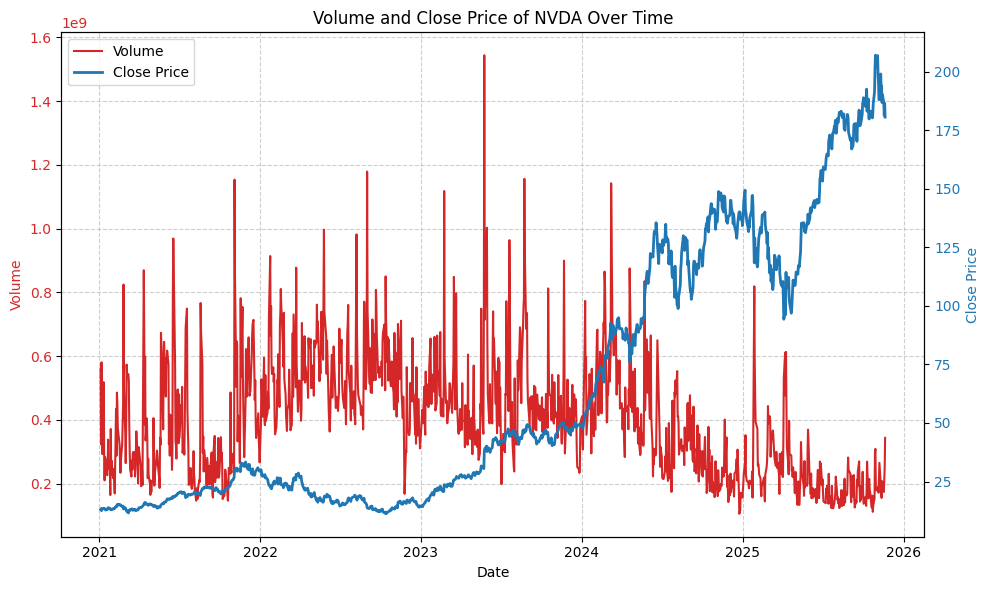

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot VOLUME on the LEFT y-axis
ax1.plot(df_input.index, df_input['Volume'], color='tab:red', label='Volume', linewidth=1.5)
ax1.set_xlabel('Date')
ax1.set_ylabel('Volume', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot CLOSE PRICE on the RIGHT y-axis
ax2 = ax1.twinx()
ax2.plot(df_input.index, df_input['Close'], color='tab:blue', label='Close Price', linewidth=2)
ax2.set_ylabel('Close Price', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Title
plt.title(f'Volume and Close Price of {Stock_comp} Over Time')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()

Based on the **df_input** data (volume and closing price for every day, indexed by the date) you are going to **predict the closing stock value for the next day, based on the volume and closing stock values of the last 5 days**.

From here you should prepare your data and turn it into a time-series problem. Set the closing price of the next day (t+1) as target (label) for this day (t).

Next to the volume and closing price of today (t), also include the volume and closing prices of the last 4 days as features of your data (t-1)(t-2)(t-3)(t-4).

Use the Pandas shift function to apply it to the volume and closing price column to add a new target column as well as the feature columns.

Are there any other or better (lagged) features, given daily volume and closing price, that might help to do the prediction? How could you tell?

**You have to make a data model and then evaluate the model with a suitable metric. For the datamodel, try different (lagged) features, try different suitable algorithms and pick the best performing algorithm. Visualize the prediction.**

In [15]:
def split_date_index(df):
    """
    Extracts Year, Month, Day, and Unix Timestamp from the DatetimeIndex.
    """
    df_new = df.copy()
    
   
    df_new['Year'] = df_new.index.year
    df_new['Month'] = df_new.index.month
    df_new['Day'] = df_new.index.day
    
    df_new['Timestamp'] = df_new.index.astype('int64') // 10**9 # convert to seconds
    
    return df_new
    
df_input = split_date_index(df_input)
df_input

Price,Volume,Close,Year,Month,Day,Timestamp
Ticker,NVDA,NVDA,,,,
Date,,,,,,
2021-01-04,560640000,13.077454,2021,1,4,1609718400
2021-01-05,322760000,13.367904,2021,1,5,1609804800
2021-01-06,580424000,12.579824,2021,1,6,1609891200
2021-01-07,461480000,13.307322,2021,1,7,1609977600
2021-01-08,292528000,13.240256,2021,1,8,1610064000
...,...,...,...,...,...,...
2025-11-14,186591900,190.169998,2025,11,14,1763078400
2025-11-17,173628900,186.600006,2025,11,17,1763337600


In [16]:
def create_time_series_data(df, target_col, steps=5, test_size=0.2, median=False ,mean =False):
    df_result = df.copy()
    df_result.columns = df_result.columns.get_level_values(0)
    df_result = df_result.sort_index(axis=1)



    
    new_target_col = f'{target_col}(t+1)'
    df_result.rename(columns={target_col: new_target_col}, inplace=True)

    features = []
    for i in range(steps):
        col_name = f'{target_col}(t-{i})'
        features.append(col_name)
        df_result[col_name] = df_result[new_target_col].shift(-steps)
    
    
    df_result.dropna(inplace=True)
    
    if median:
        df_result['t_mean'] = df_result[features].median(axis=1)

    if mean:
        df_result['t_average'] = df_result[features].mean(axis=1)
  

    X = df_result.drop(columns=new_target_col)
    y = df_result[new_target_col]

    return new_target_col,df_result

target_col, df_time_series = create_time_series_data(df=df_input, target_col='Close',median=True,mean=True)

df_time_series

Price,Close(t+1),Day,Month,Timestamp,Volume,Year,Close(t-0),Close(t-1),Close(t-2),Close(t-3),Close(t-4),t_mean,t_average
Date,,,,,,,,,,,,,
2021-01-04,13.077454,4,1,1609718400,560640000,2021,13.584056,13.584056,13.584056,13.584056,13.584056,13.584056,13.584056
2021-01-05,13.367904,5,1,1609804800,322760000,2021,13.447685,13.447685,13.447685,13.447685,13.447685,13.447685,13.447685
2021-01-06,12.579824,6,1,1609891200,580424000,2021,13.494555,13.494555,13.494555,13.494555,13.494555,13.494555,13.494555
2021-01-07,13.307322,7,1,1609977600,461480000,2021,13.163965,13.163965,13.163965,13.163965,13.163965,13.163965,13.163965
2021-01-08,13.240256,8,1,1610064000,292528000,2021,12.824153,12.824153,12.824153,12.824153,12.824153,12.824153,12.824153
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-07,188.149994,7,11,1762473600,264942300,2025,190.169998,190.169998,190.169998,190.169998,190.169998,190.169998,190.169998
2025-11-10,199.050003,10,11,1762732800,198897100,2025,186.600006,186.600006,186.600006,186.600006,186.600006,186.600006,186.600006
2025-11-11,193.160004,11,11,1762819200,176483300,2025,181.360001,181.360001,181.360001,181.360001,181.360001,181.360001,181.360001


# wrong first attempt

This attempt was wrong becouse alle data gaat over t+0 alleen de close = t+1 geworden. also not all historical data is tackene in toe account

In [17]:
import pandas as pd

def create_time_series_data(df, target_col, steps=5, median=False, mean=False):
    df_result = df.copy()
    if isinstance(df_result.columns, pd.MultiIndex):
        df_result.columns = df_result.columns.get_level_values(0)
    
    original_cols = df_result.columns.tolist()
    
    print(f"🔄 Creating features for {len(original_cols)} columns over {steps} steps...")

    for col in original_cols:
        current_col_lags = [col]
        
        for i in range(1, steps + 1):
            lag_name = f'{col}(t-{i})'
            df_result[lag_name] = df_result[col].shift(i)
            current_col_lags.append(lag_name)

        if mean:
            df_result[f'{col}_History_Mean'] = df_result[current_col_lags].mean(axis=1)
        
        if median:
            df_result[f'{col}_History_Median'] = df_result[current_col_lags].median(axis=1)

    new_target_name = f'{target_col}(t+1)'
    df_result[new_target_name] = df_result[target_col].shift(-1)
    

    df_result.dropna(inplace=True)
    


    
    return new_target_name, df_result


target_col, df_time_series = create_time_series_data(df_input,target_col='Close',median=True,mean=True)


df_time_series

🔄 Creating features for 6 columns over 5 steps...


Price,Volume,Close,Year,Month,Day,Timestamp,Volume(t-1),Volume(t-2),Volume(t-3),Volume(t-4),...,Day_History_Mean,Day_History_Median,Timestamp(t-1),Timestamp(t-2),Timestamp(t-3),Timestamp(t-4),Timestamp(t-5),Timestamp_History_Mean,Timestamp_History_Median,Close(t+1)
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-11,518344000,13.584056,2021,1,11,1610323200,292528000.0,461480000.0,580424000.0,322760000.0,...,6.833333,6.5,1.610064e+09,1.609978e+09,1.609891e+09,1.609805e+09,1.609718e+09,1.609963e+09,1.609934e+09,13.447685
2021-01-12,291476000,13.447685,2021,1,12,1610409600,518344000.0,292528000.0,461480000.0,580424000.0,...,8.166667,7.5,1.610323e+09,1.610064e+09,1.609978e+09,1.609891e+09,1.609805e+09,1.610078e+09,1.610021e+09,13.494555
2021-01-13,210028000,13.494555,2021,1,13,1610496000,291476000.0,518344000.0,292528000.0,461480000.0,...,9.500000,9.5,1.610410e+09,1.610323e+09,1.610064e+09,1.609978e+09,1.609891e+09,1.610194e+09,1.610194e+09,13.163965
2021-01-14,283120000,13.163965,2021,1,14,1610582400,210028000.0,291476000.0,518344000.0,292528000.0,...,10.833333,11.5,1.610496e+09,1.610410e+09,1.610323e+09,1.610064e+09,1.609978e+09,1.610309e+09,1.610366e+09,12.824153
2021-01-15,277780000,12.824153,2021,1,15,1610668800,283120000.0,210028000.0,291476000.0,518344000.0,...,12.166667,12.5,1.610582e+09,1.610496e+09,1.610410e+09,1.610323e+09,1.610064e+09,1.610424e+09,1.610453e+09,12.989447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-13,207423100,186.860001,2025,11,13,1762992000,154935300.0,176483300.0,198897100.0,264942300.0,...,9.833333,10.5,1.762906e+09,1.762819e+09,1.762733e+09,1.762474e+09,1.762387e+09,1.762718e+09,1.762776e+09,190.169998
2025-11-14,186591900,190.169998,2025,11,14,1763078400,207423100.0,154935300.0,176483300.0,198897100.0,...,11.166667,11.5,1.762992e+09,1.762906e+09,1.762819e+09,1.762733e+09,1.762474e+09,1.762834e+09,1.762862e+09,186.600006
2025-11-17,173628900,186.600006,2025,11,17,1763337600,186591900.0,207423100.0,154935300.0,176483300.0,...,12.833333,12.5,1.763078e+09,1.762992e+09,1.762906e+09,1.762819e+09,1.762733e+09,1.762978e+09,1.762949e+09,181.360001


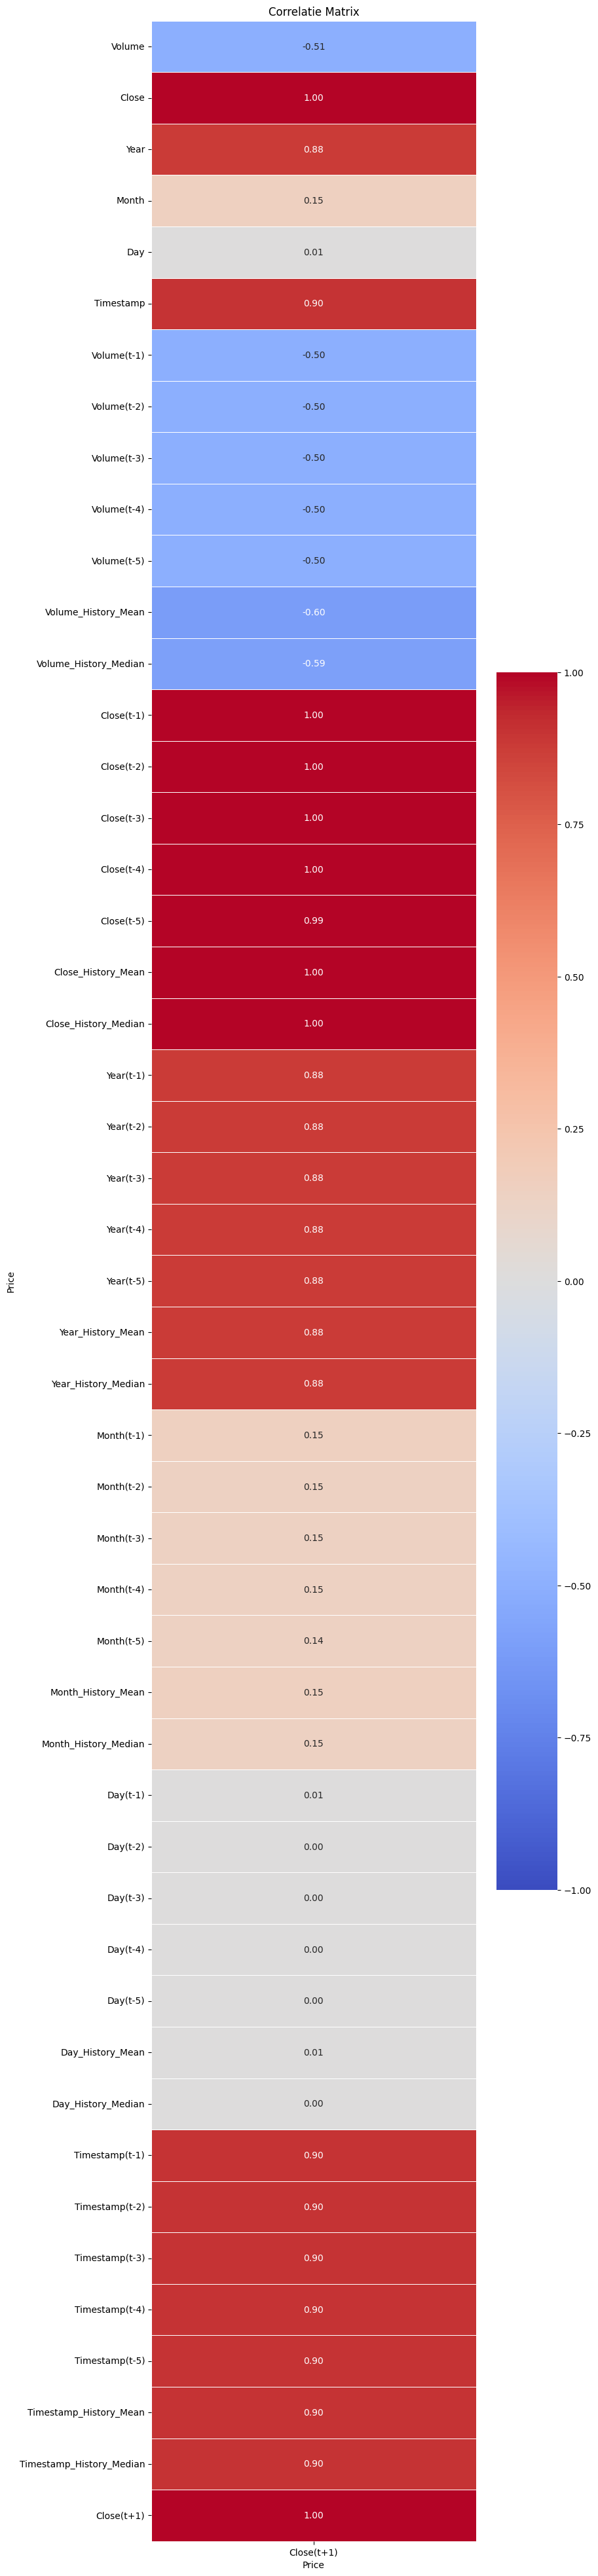

In [18]:
import seaborn as sns
corr_matrix = df_time_series.corr()

corr_matrix = corr_matrix[[target_col]]


plt.figure(figsize=(8, 50)) 
sns.heatmap(
    corr_matrix, 
    annot=True,        
    fmt=".2f",         
    cmap='coolwarm',   
    vmin=-1, vmax=1,   
    linewidths=0.5    
)

plt.title("Correlatie Matrix")
plt.show()

Alle exept day and mond seem relevant

🔄 Calculating correlations up to lag 730...


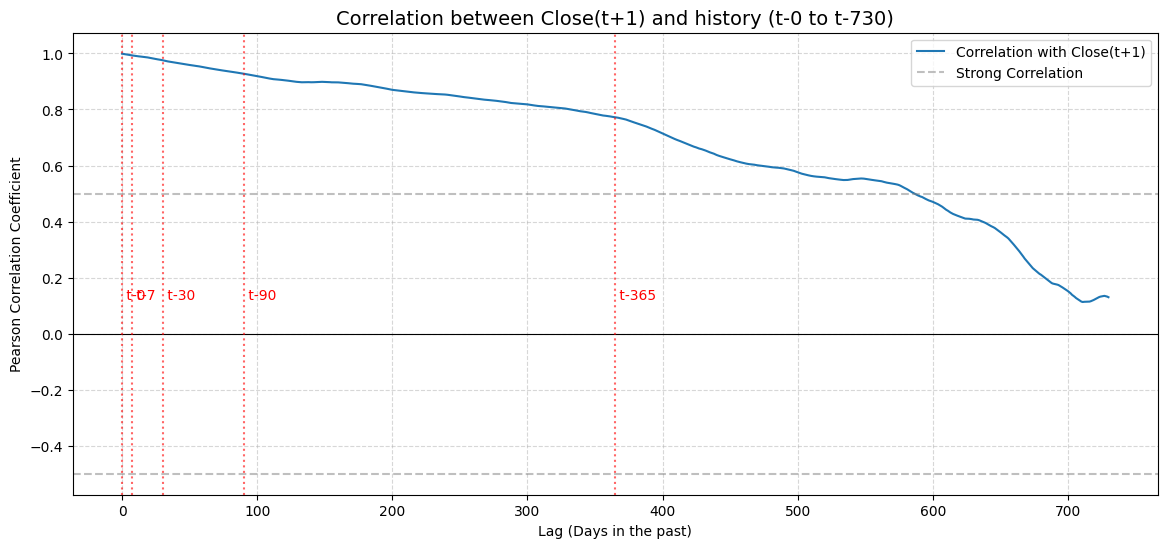

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_lag_correlations(df, target_col='Close', max_lag=356):
    """
    Calculates and plots the correlation between target(t+1) and target(t-k) 
    for k = 0 to max_lag.
    """
    print(f"🔄 Calculating correlations up to lag {max_lag}...")

    data_series = df[target_col]
    if isinstance(data_series, pd.DataFrame):
        data_series = data_series.iloc[:, 0]
        
    y_target = data_series.shift(-1)
    
    correlations = []
    lags = range(max_lag + 1)

    for lag in lags:
        feat = data_series.shift(lag)
        
        corr = y_target.corr(feat)
        correlations.append(corr)
        
    plt.figure(figsize=(14, 6))
    
    plt.plot(lags, correlations, label=f'Correlation with {target_col}(t+1)', color='#1f77b4', linewidth=1.5)
    

    plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
    plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Strong Correlation')
    plt.axhline(-0.5, color='gray', linestyle='--', alpha=0.5)

    highlights = [0, 7, 30, 90, 365]
    for h in highlights:
        if h <= max_lag:
  
            if not np.isnan(correlations[h]):
                plt.axvline(h, color='red', linestyle=':', alpha=0.6)
                plt.text(h, min(correlations), f' t-{h}', color='red', verticalalignment='bottom')

    plt.title(f"Correlation between {target_col}(t+1) and history (t-0 to t-{max_lag})", fontsize=14)
    plt.xlabel("Lag (Days in the past)")
    plt.ylabel("Pearson Correlation Coefficient")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


corr_data = plot_lag_correlations(df_time_series, target_col='Close', max_lag=365*2)

In [20]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.exceptions import ConvergenceWarning

current_dir = os.getcwd()
path_to_add = os.path.abspath(os.path.join(current_dir, '../../Week_02/Regression'))
if path_to_add not in sys.path:
    sys.path.append(path_to_add)

from RegressionEvaluator import RegressionEvaluator

reg_eval = RegressionEvaluator(name="Stock_predictor",time_series = False)

day_cols = [col for col in df_time_series.columns if 'Day' in col]
month_cols = [col for col in df_time_series.columns if 'Month' in col]
mean_cols = [col for col in df_time_series.columns if 'Mean' in col]
median_cols = [col for col in df_time_series.columns if 'Median' in col]
volume_cols = [col for col in df_time_series.columns if 'Volume' in col]
hist_cols = [col for col in df_time_series.columns if '(t-' in col]


reg_eval.add_option(scaling=False)
reg_eval.add_option(scaling=False, cols_to_drop=day_cols+month_cols)
reg_eval.add_option(scaling=False, cols_to_drop=mean_cols+median_cols)
reg_eval.add_option(scaling=False, cols_to_drop=day_cols+month_cols+mean_cols+median_cols)
reg_eval.add_option(scaling=False, cols_to_drop=day_cols+month_cols+mean_cols+median_cols+volume_cols)
reg_eval.add_option(scaling=False, cols_to_drop=day_cols+month_cols+hist_cols)

reg_eval.add_model(
    name='LinearRegression',
    model=LinearRegression(),
    params={} # No hyperparameters for standard Linear Regression
)

reg_eval.add_model(
    name='RandomForest',
    model=RandomForestRegressor(random_state=42, n_jobs=-1),
    params={
        'n_estimators': [100, 200,300,500,1000],
        'max_depth': [5, 10,50, None]
    }
)

reg_eval.add_model(
    name='XGBoost',
    model=XGBRegressor(random_state=42, n_jobs=-1),
    params={
        'n_estimators': [100, 200,500,1000],
        'max_depth': [3, 5,7,10,20],
        'learning_rate': [0.01, 0.1,0.2]
    }
)

reg_eval.add_model(
    name='Ridge',
    model=Ridge(random_state=42),
    params={
        'alpha': [0.1, 1.0, 10.0, 100.0], 
        'fit_intercept': [True]
    }
)

reg_eval.add_model(
    name='Lasso',
    model=Lasso(random_state=42),
    params={
        'alpha': [0.01, 0.1, 1.0, 10.0],
        'fit_intercept': [True]
    }
)


reg_eval.run_experiments(df=df_time_series, target_col= target_col, cv =2,refit='r2') 
reg_eval.print_results()


🚀 START REGRESSION EXPERIMENT: STOCK_PREDICTOR
📊 Target Column: 'Close(t+1)'
📊 Time Series Mode: False
📊 Optimizing for: r2

--- ⚙️ Processing Opt0_S0_D0 ---
   ✅ LinearRegression: r2=0.9977
   ✅ RandomForest: r2=0.9974
   ✅ XGBoost: r2=0.9972
   ✅ Ridge: r2=0.9978
   ✅ Lasso: r2=0.9979

--- ⚙️ Processing Opt1_S0_D0 ---
   ✅ LinearRegression: r2=0.9978


/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=4.78373e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


   ✅ RandomForest: r2=0.9973
   ✅ XGBoost: r2=0.9972
   ✅ Ridge: r2=0.9979
   ✅ Lasso: r2=0.9979

--- ⚙️ Processing Opt2_S0_D0 ---
   ✅ LinearRegression: r2=0.9978
   ✅ RandomForest: r2=0.9975
   ✅ XGBoost: r2=0.9972
   ✅ Ridge: r2=0.9978
   ✅ Lasso: r2=0.9979

--- ⚙️ Processing Opt3_S0_D0 ---
   ✅ LinearRegression: r2=0.9979


/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.08881e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.09602e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.13263e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.1441e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear

   ✅ RandomForest: r2=0.9974
   ✅ XGBoost: r2=0.9972
   ✅ Ridge: r2=0.9979
   ✅ Lasso: r2=0.9979

--- ⚙️ Processing Opt4_S0_D0 ---
   ✅ LinearRegression: r2=0.9979


/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=3.89609e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.33142e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.05482e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=1.66232e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linea

   ✅ RandomForest: r2=0.9973
   ✅ XGBoost: r2=0.9973
   ✅ Ridge: r2=0.9979
   ✅ Lasso: r2=0.9979

--- ⚙️ Processing Opt5_S0_D0 ---
   ✅ LinearRegression: r2=0.9978


/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.32239e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=7.51866e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.82626e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.44968e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linea

   ✅ RandomForest: r2=0.9973
   ✅ XGBoost: r2=0.9972
   ✅ Ridge: r2=0.9978
   ✅ Lasso: r2=0.9979

🏁 Experiments completed!

=== [Stock_predictor] Top 20 Results (Sorted by r2) ===
           Model Option_ID                 Config  root_mean_squared_error       r2  mean_absolute_error  max_depth  n_estimators  learning_rate  alpha fit_intercept
           Lasso      Opt4 Opt4 (Scale:No Dum:No)                 2.523221 0.997932             1.484322        NaN           NaN            NaN   0.10          True
           Lasso      Opt3 Opt3 (Scale:No Dum:No)                 2.527519 0.997925             1.494528        NaN           NaN            NaN   0.10          True
           Lasso      Opt1 Opt1 (Scale:No Dum:No)                 2.529471 0.997922             1.497268        NaN           NaN            NaN   0.10          True
           Lasso      Opt4 Opt4 (Scale:No Dum:No)                 2.533526 0.997917             1.499390        NaN           NaN            NaN   0.01     

/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=4.03227e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=6.88121e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.18709e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.32592e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/robin/.venv/lib/python3.10/site-packages/sklearn/linea

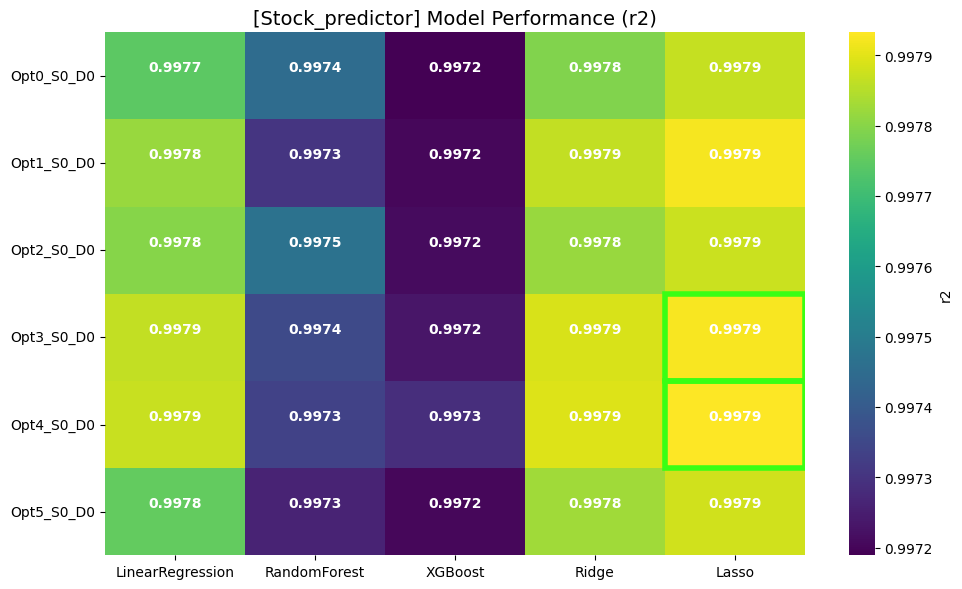

In [21]:
reg_eval.plot_heatmap(metric = 'r2')

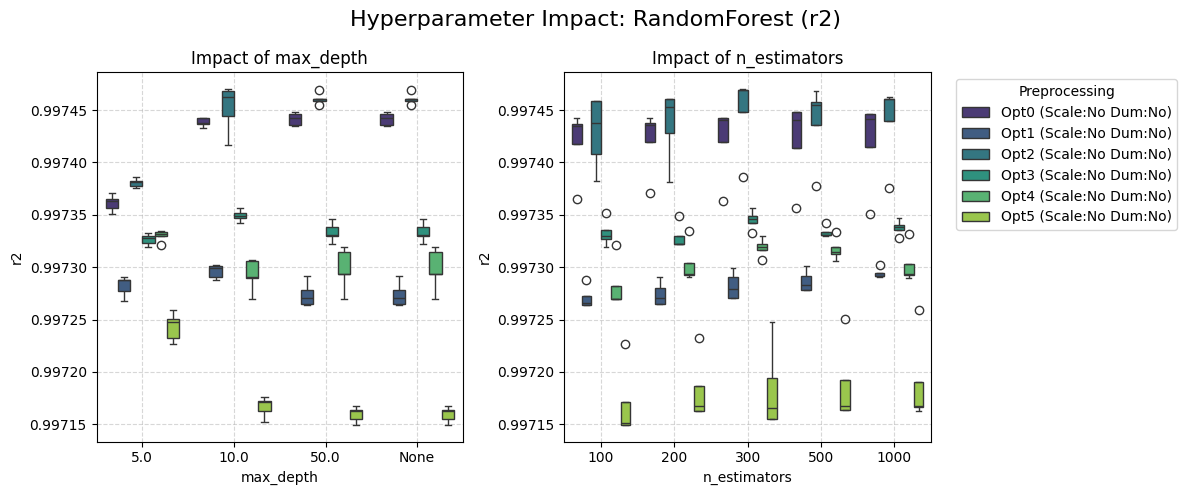

In [22]:
reg_eval.plot_parameter_impact( target_model='RandomForest', metric='r2')